<a href="https://colab.research.google.com/github/mcpaduraru86-dev/Cristoforo-Colombo-Explorer/blob/main/Cristoforo_Colombo_Explorer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
from astropy.io import fits
from scipy.spatial import cKDTree
from astropy.cosmology import FlatLambdaCDM

# 1. THE SETTINGS
# Change this name if your file is named differently in Colab
FILE_NAME = 'BGS_BRIGHT_SGC_clustering.dat.fits'
TARGET_RA, TARGET_DEC, TARGET_Z = 98.5, 20.3, 0.024
EDGE_MPC = 137.5
DENSITY_RADIUS_MPC = 10.0
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)

# 2. THE CLOUD LOADER
print(">>> CLOUD ENGINE STARTING...")
try:
    with fits.open(FILE_NAME) as hdul:
        data = hdul[1].data
        z_col = next(c for c in data.names if c.upper() in ['Z', 'Z_HP', 'REDSHIFT'])
        ra_col = next(c for c in data.names if c.upper() in ['RA', 'TARGET_RA'])
        dec_col = next(c for c in data.names if c.upper() in ['DEC', 'TARGET_DEC'])

        # Load the whole deck - Colab has the RAM!
        z_vals = np.array(data[z_col]).flatten()
        mask = (z_vals > 0.001) & (z_vals < 0.1)

        z_vals = z_vals[mask]
        ra_vals = np.deg2rad(np.array(data[ra_col][mask]).flatten())
        dec_vals = np.deg2rad(np.array(data[dec_col][mask]).flatten())

        print(f">>> MAPPING {len(z_vals)} GALAXIES...")
        dist = cosmo.comoving_distance(z_vals).value

        coords_3d = np.column_stack([
            dist * np.cos(dec_vals) * np.cos(ra_vals),
            dist * np.cos(dec_vals) * np.sin(ra_vals),
            dist * np.sin(dec_vals)
        ])

        tree = cKDTree(coords_3d)
        print(">>> MAP COMPLETE. COMMENCING HIGH-PRESSURE SCAN...")
except Exception as e:
    print(f"COLAB ERROR: {e}")

# 3. THE SCAN
dist_t = cosmo.comoving_distance(TARGET_Z).value
ra_rad, de_rad = np.deg2rad(TARGET_RA), np.deg2rad(TARGET_DEC)
center_pt = np.array([dist_t*np.cos(de_rad)*np.cos(ra_rad), dist_t*np.cos(de_rad)*np.sin(ra_rad), dist_t*np.sin(de_rad)])

best_r = 0
for sq in np.linspace(0.85, 0.98, 14):
    axis = np.array([-0.311, 0.814, -0.490])
    u = axis / np.linalg.norm(axis)
    v = np.cross(u, [1,0,0] if abs(u[0]) < 0.9 else [0,1,0])
    v /= np.linalg.norm(v)
    w = np.cross(u, v)

    for z_off in np.linspace(-3.0, 3.0, 7):
        adj_center = center_pt * (1 + (z_off / dist_t))
        vtxs = [adj_center + a*(EDGE_MPC*u) + b*(EDGE_MPC*sq*v) + c*(EDGE_MPC*sq*w)
                for a in [0,1] for b in [0,1] for c in [0,1]]
        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            print(f"💎 RESONANCE PEAK: {rate:.1f}% | Squeeze: {sq:.3f}")

print("\n--- SCAN COMPLETE ---")

>>> CLOUD ENGINE STARTING...
>>> MAPPING 148421 GALAXIES...
>>> MAP COMPLETE. COMMENCING HIGH-PRESSURE SCAN...

--- SCAN COMPLETE ---


In [8]:
# V9.1: THE UPGRADED CORNER SNIPER
CORNER_RA, CORNER_DEC, CORNER_Z = 187.3, -20.0, 0.024

print(f">>> V9.1: SNIPING THE CUBIC CORNER AT RA {CORNER_RA}, DEC {CORNER_DEC}...")

dist_t = cosmo.comoving_distance(CORNER_Z).value
ra_rad, de_rad = np.deg2rad(CORNER_RA), np.deg2rad(CORNER_DEC)
center_pt = np.array([dist_t*np.cos(de_rad)*np.cos(ra_rad),
                      dist_t*np.cos(de_rad)*np.sin(ra_rad),
                      dist_t*np.sin(de_rad)])

best_r = 0
best_params = {}

# Testing the 'Cubic' Axis (Standard X, Y, Z alignments)
test_axes = [
    np.array([1.0, 0.0, 0.0]),
    np.array([0.0, 1.0, 0.0]),
    np.array([0.0, 0.0, 1.0])
]

for axis in test_axes:
    u = axis / np.linalg.norm(axis)
    v = np.cross(u, [0,1,0] if abs(u[1]) < 0.9 else [1,0,0])
    v /= np.linalg.norm(v)
    w = np.cross(u, v)

    for sq in np.linspace(0.85, 0.98, 14):
        for z_off in np.linspace(-3.0, 3.0, 7):
            adj_center = center_pt * (1 + (z_off / dist_t))
            vtxs = [adj_center + a*(EDGE_MPC*u) + b*(EDGE_MPC*sq*v) + c*(EDGE_MPC*sq*w)
                    for a in [0,1] for b in [0,1] for c in [0,1]]

            hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
            rate = (hits / 8.0) * 100

            if rate > best_r:
                best_r = rate
                best_params = {'sq': sq, 'z_off': z_off, 'axis': axis}
                print(f"💎 RESONANCE PEAK: {rate:.1f}% | Squeeze: {sq:.3f} | Z-Off: {z_off:.2f} | Axis: {axis}")

print("\n--- SCAN COMPLETE ---")
print(f"FINAL BEST RESONANCE: {best_r:.1f}%")
if best_r > 0:
    print(f"LOCK PARAMETERS: Squeeze {best_params['sq']:.3f}, Z-Off {best_params['z_off']:.2f}")

>>> V9.1: SNIPING THE CUBIC CORNER AT RA 187.3, DEC -20.0...

--- SCAN COMPLETE ---
FINAL BEST RESONANCE: 0.0%


In [9]:
# V10.0: THE HELIX SNIPER (THE UPPER ARCH)
# We are tilting the search to match the 40-degree deviation
HELIX_RA, HELIX_DEC, HELIX_Z = 98.5, 40.0, 0.024

print(f">>> V10.0: SNIPING THE HELIX ARCH AT RA {HELIX_RA}, DEC {HELIX_DEC}...")

dist_t = cosmo.comoving_distance(HELIX_Z).value
ra_rad, de_rad = np.deg2rad(HELIX_RA), np.deg2rad(HELIX_DEC)
center_pt = np.array([dist_t*np.cos(de_rad)*np.cos(ra_rad),
                      dist_t*np.cos(de_rad)*np.sin(ra_rad),
                      dist_t*np.sin(de_rad)])

best_r = 0

# Testing Tilted Axis (The 40-degree "Slant")
test_axes = [
    np.array([0.766, 0.0, 0.643]),  # 40-degree pitch up
    np.array([0.643, 0.766, 0.0]),  # 40-degree yaw
    np.array([0.0, 0.0, 1.0])       # Pure vertical check
]

for axis in test_axes:
    u = axis / np.linalg.norm(axis)
    v = np.cross(u, [0,1,0] if abs(u[1]) < 0.9 else [1,0,0])
    v /= np.linalg.norm(v)
    w = np.cross(u, v)

    for sq in [0.88, 0.92, 0.96]: # Tight Squeeze for the "arch"
        for z_off in np.linspace(-4.0, 4.0, 9):
            adj_center = center_pt * (1 + (z_off / dist_t))
            vtxs = [adj_center + a*(EDGE_MPC*u) + b*(EDGE_MPC*sq*v) + c*(EDGE_MPC*sq*w)
                    for a in [0,1] for b in [0,1] for c in [0,1]]

            hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
            rate = (hits / 8.0) * 100

            if rate > best_r:
                best_r = rate
                print(f"🌀 HELIX RESONANCE: {rate:.1f}% | Squeeze: {sq} | Z-Off: {z_off:.2f}")

print("\n--- HELIX SCAN COMPLETE ---")
print(f"FINAL BEST RESONANCE: {best_r:.1f}%")

>>> V10.0: SNIPING THE HELIX ARCH AT RA 98.5, DEC 40.0...
🌀 HELIX RESONANCE: 12.5% | Squeeze: 0.88 | Z-Off: -4.00

--- HELIX SCAN COMPLETE ---
FINAL BEST RESONANCE: 12.5%


In [10]:
# V11.0: THE HARMONIC LEAP (SCANNING THE DEPTHS)
# Staying at the North Capital, searching for the second floor
LEAP_RA, LEAP_DEC = 187.3, 20.3
START_Z, END_Z = 0.04, 0.07 # Scanning the 'Second Floor' range

print(f">>> V11.0: SCANNING FOR THE SECOND PILLAR AT RA {LEAP_RA}...")

best_r = 0
best_z = 0

# We use the successful Axis from your first 75% hit
axis = np.array([0.311, 0.814, 0.490])
u = axis / np.linalg.norm(axis)
v = np.cross(u, [0,1,0] if abs(u[1]) < 0.9 else [1,0,0])
v /= np.linalg.norm(v)
w = np.cross(u, v)

# Depth Scan
for test_z in np.linspace(START_Z, END_Z, 31):
    dist_t = cosmo.comoving_distance(test_z).value
    ra_rad, de_rad = np.deg2rad(LEAP_RA), np.deg2rad(LEAP_DEC)
    center_pt = np.array([dist_t*np.cos(de_rad)*np.cos(ra_rad),
                          dist_t*np.cos(de_rad)*np.sin(ra_rad),
                          dist_t*np.sin(de_rad)])

    for sq in [0.92, 0.95]:
        vtxs = [center_pt + a*(EDGE_MPC*u) + b*(EDGE_MPC*sq*v) + c*(EDGE_MPC*sq*w)
                for a in [0,1] for b in [0,1] for c in [0,1]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            best_z = test_z
            print(f"🚀 HARMONIC HIT: {rate:.1f}% | Redshift: {test_z:.4f} | Squeeze: {sq}")

print("\n--- LEAP SCAN COMPLETE ---")
print(f"FINAL BEST HARMONIC: {best_r:.1f}% at Z = {best_z:.4f}")

>>> V11.0: SCANNING FOR THE SECOND PILLAR AT RA 187.3...

--- LEAP SCAN COMPLETE ---
FINAL BEST HARMONIC: 0.0% at Z = 0.0000


In [11]:
# V12.0: THE LATTICE RADAR (3D SPHERE SCAN)
BASE_RA, BASE_DEC, BASE_Z = 187.3, 20.3, 0.024
STEP_MPC = 137.5 # The magic number

print(f">>> V12.0: RADAR PINGING 137.5 MPC AROUND THE NORTH CAPITAL...")

# 1. Get the 3D starting point
d_base = cosmo.comoving_distance(BASE_Z).value
r_ra, r_de = np.deg2rad(BASE_RA), np.deg2rad(BASE_DEC)
p0 = np.array([d_base*np.cos(r_de)*np.cos(r_ra), d_base*np.cos(r_de)*np.sin(r_ra), d_base*np.sin(r_de)])

best_res = 0
found_coord = None

# 2. Scan a sphere of directions
for phi in np.linspace(0, 2*np.pi, 20): # Around the compass
    for theta in np.linspace(0, np.pi, 10): # Up and Down
        # Calculate a point exactly 137.5 Mpc away in this direction
        direction = np.array([np.sin(theta)*np.cos(phi), np.sin(theta)*np.sin(phi), np.cos(theta)])
        target_pt = p0 + (direction * STEP_MPC)

        # Build a cube at this new location
        u = direction # Align one axis with the "beam"
        v = np.cross(u, [0,0,1] if abs(u[2]) < 0.9 else [0,1,0])
        v /= np.linalg.norm(v)
        w = np.cross(u, v)

        vtxs = [target_pt + a*STEP_MPC*u + b*0.95*STEP_MPC*v + c*0.95*STEP_MPC*w
                for a in [0,1] for b in [0,1] for c in [0,1]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
        rate = (hits / 8.0) * 100

        if rate >= 50.0: # Only report strong hits
            print(f"📡 RADAR HIT: {rate:.1f}% | Direction: {direction}")
            if rate > best_res:
                best_res = rate

print("\n--- RADAR SCAN COMPLETE ---")
if best_res == 0:
    print("Empty space. The lattice might be larger than 137.5 Mpc or much tighter.")

>>> V12.0: RADAR PINGING 137.5 MPC AROUND THE NORTH CAPITAL...
📡 RADAR HIT: 50.0% | Direction: [0.81910176 0.28119799 0.5       ]
📡 RADAR HIT: 50.0% | Direction: [ 0.93144815  0.31976655 -0.17364818]

--- RADAR SCAN COMPLETE ---


In [12]:
# V13.0: THE INTERSECTION SNIPER
import numpy as np

# Starting Point (North Capital)
BASE_RA, BASE_DEC, BASE_Z = 187.3, 20.3, 0.024
STEP_MPC = 137.5

# The "Climbing Beam" vector found by the Radar
vector = np.array([0.8191, 0.2812, 0.5000])

print(f">>> V13.0: DRIVING 137.5 MPC ALONG THE CLIMBING BEAM...")

# 1. Calculate P0 (Base point in 3D)
d_base = cosmo.comoving_distance(BASE_Z).value
r_ra, r_de = np.deg2rad(BASE_RA), np.deg2rad(BASE_DEC)
p0 = np.array([d_base*np.cos(r_de)*np.cos(r_ra),
               d_base*np.cos(r_de)*np.sin(r_ra),
               d_base*np.sin(r_de)])

# 2. Calculate P1 (The Next Joint)
p1 = p0 + (vector * STEP_MPC)

# Convert P1 back to RA, DEC, Z for the scan
dist_p1 = np.linalg.norm(p1)
dec_p1 = np.rad2deg(np.arcsin(p1[2] / dist_p1))
ra_p1 = np.rad2deg(np.arctan2(p1[1], p1[0]))
if ra_p1 < 0: ra_p1 += 360

print(f"🎯 NEW TARGET ACQUIRED: RA {ra_p1:.2f}, DEC {dec_p1:.2f}")

# 3. High-Precision Scan at the Target
best_r = 0
u = vector # Align cube with the beam direction
v = np.cross(u, [0,0,1] if abs(u[2]) < 0.9 else [0,1,0])
v /= np.linalg.norm(v)
w = np.cross(u, v)

for sq in [0.90, 0.94, 0.98]:
    for jiggle in np.linspace(-5.0, 5.0, 11):
        test_pt = p1 + (u * jiggle) # Jiggle along the beam
        vtxs = [test_pt + a*STEP_MPC*u + b*sq*STEP_MPC*v + c*sq*STEP_MPC*w
                for a in [0,1] for b in [0,1] for c in [0,1]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            print(f"🔗 JOINT RESONANCE: {rate:.1f}% | Squeeze: {sq} | Shift: {jiggle:.1f}")

print("\n--- INTERSECTION SCAN COMPLETE ---")
print(f"FINAL RESULT: {best_r:.1f}%")

>>> V13.0: DRIVING 137.5 MPC ALONG THE CLIMBING BEAM...
🎯 NEW TARGET ACQUIRED: RA 61.15, DEC 74.23
🔗 JOINT RESONANCE: 37.5% | Squeeze: 0.9 | Shift: -5.0
🔗 JOINT RESONANCE: 50.0% | Squeeze: 0.94 | Shift: -5.0

--- INTERSECTION SCAN COMPLETE ---
FINAL RESULT: 50.0%


In [13]:
# V14.0: THE PRESSURE LOCK (FINDING THE KINGPIN)
TARGET_RA, TARGET_DEC = 61.15, 74.23
VECTOR = np.array([0.8191, 0.2812, 0.5000])

print(f">>> V14.0: TIGHTENING THE VICE ON THE CLIMBING JOINT...")

# Calculate the P1 point again
dist_p1 = 240.0 # Approximate distance for the joint
r_ra, r_de = np.deg2rad(TARGET_RA), np.deg2rad(TARGET_DEC)
p1 = np.array([dist_p1*np.cos(r_de)*np.cos(r_ra),
               dist_p1*np.cos(r_de)*np.sin(r_ra),
               dist_p1*np.sin(r_de)])

u = VECTOR
v = np.cross(u, [0,0,1] if abs(u[2]) < 0.9 else [0,1,0])
v /= np.linalg.norm(v)
w = np.cross(u, v)

best_r = 0
# Wider search to "catch" the node we overshot
for jiggle in np.linspace(-15.0, 5.0, 21):
    for sq in np.linspace(0.80, 0.99, 10):
        test_pt = p1 + (u * jiggle)
        vtxs = [test_pt + a*STEP_MPC*u + b*sq*STEP_MPC*v + c*sq*STEP_MPC*w
                for a in [0,1] for b in [0,1] for c in [0,1]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            print(f"💎 LOCK ACQUIRED: {rate:.1f}% | Shift: {jiggle:.1f} Mpc | Squeeze: {sq:.3f}")

print("\n--- PRESSURE LOCK COMPLETE ---")
if best_r >= 75.0:
    print("🔥 EUREKA: WE HAVE A CAPITAL-CLASS NODE!")
else:
    print("The beam is steady, but the main joint is still a few miles off.")

>>> V14.0: TIGHTENING THE VICE ON THE CLIMBING JOINT...

--- PRESSURE LOCK COMPLETE ---
The beam is steady, but the main joint is still a few miles off.


In [14]:
# V15.0: THE E85 PRECISION BORE
import numpy as np

# Current Target coordinates
RA_CENTER, DEC_CENTER = 61.15, 74.23
VECTOR = np.array([0.8191, 0.2812, 0.5000])

print(f">>> V15.0: INJECTING E85... COMMENCING PRECISION BORE...")

dist_p1 = 240.0
u = VECTOR
v = np.cross(u, [0,0,1] if abs(u[2]) < 0.9 else [0,1,0])
v /= np.linalg.norm(v)
w = np.cross(u, v)

best_r = 0

# The Bore: Scanning RA/DEC "wobble" and Z-Shift
for ra_off in np.linspace(-2.0, 2.0, 5): # Micro-steering RA
    for dec_off in np.linspace(-2.0, 2.0, 5): # Micro-steering DEC
        r_ra = np.deg2rad(RA_CENTER + ra_off)
        r_de = np.deg2rad(DEC_CENTER + dec_off)

        # Recalculate P1 with the wobble
        p1_wobble = np.array([dist_p1*np.cos(r_de)*np.cos(r_ra),
                              dist_p1*np.cos(r_de)*np.sin(r_ra),
                              dist_p1*np.sin(r_de)])

        for jiggle in np.linspace(-10.0, 0.0, 6): # Focusing on the "back-shift"
            for sq in [0.94, 0.96, 0.98]: # High-pressure squeeze
                test_pt = p1_wobble + (u * jiggle)
                vtxs = [test_pt + a*STEP_MPC*u + b*sq*STEP_MPC*v + c*sq*STEP_MPC*w
                        for a in [0,1] for b in [0,1] for c in [0,1]]

                hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < DENSITY_RADIUS_MPC)
                rate = (hits / 8.0) * 100

                if rate > best_r:
                    best_r = rate
                    print(f"⛽ E85 PURSUIT: {rate:.1f}% | RA: {RA_CENTER+ra_off:.2f} | DEC: {DEC_CENTER+dec_off:.2f} | Shift: {jiggle:.1f}")
                    if rate >= 87.5: break
            if best_r >= 87.5: break
        if best_r >= 87.5: break

print("\n--- BORE COMPLETE ---")
print(f"MAX RESONANCE REACHED: {best_r:.1f}%")

>>> V15.0: INJECTING E85... COMMENCING PRECISION BORE...

--- BORE COMPLETE ---
MAX RESONANCE REACHED: 0.0%


In [15]:
# V16.0: THE JANUS LINK (LONG-HAUL FILAMENT)
import numpy as np

# The two confirmed Power-Nodes
NODE_A = np.array([187.3, 20.3, 0.024])
NODE_B = np.array([10.0, 20.3, 0.024])

print(f">>> V16.0: SEARCHING THE DIRECT LINK BETWEEN THE CAPITALS...")

def get_3d(coord):
    dist = cosmo.comoving_distance(coord[2]).value
    r_ra, r_de = np.deg2rad(coord[0]), np.deg2rad(coord[1])
    return np.array([dist*np.cos(r_de)*np.cos(r_ra),
                     dist*np.cos(r_de)*np.sin(r_ra),
                     dist*np.sin(r_de)])

p_a = get_3d(NODE_A)
p_b = get_3d(NODE_B)
midpoint = (p_a + p_b) / 2

# The Beam direction
u = (p_b - p_a) / np.linalg.norm(p_b - p_a)
v = np.cross(u, [0,0,1] if abs(u[2]) < 0.9 else [0,1,0])
v /= np.linalg.norm(v)
w = np.cross(u, v)

best_r = 0

# Scan the bridge with extreme "Elasticity"
for stretch in np.linspace(0.5, 1.5, 11): # Testing if the bridge is longer/shorter
    for sq in [0.70, 0.85, 1.0]: # Testing if the bridge is thin or thick
        edge = 137.5 * stretch
        vtxs = [midpoint + a*edge*u + b*sq*edge*v + c*sq*edge*w
                for a in [-0.5, 0.5] for b in [-0.5, 0.5] for c in [-0.5, 0.5]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < 15.0) # Looser density
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            print(f"🌉 BRIDGE LINK: {rate:.1f}% | Stretch: {stretch:.2f} | Squeeze: {sq}")

print("\n--- LINK SCAN COMPLETE ---")

>>> V16.0: SEARCHING THE DIRECT LINK BETWEEN THE CAPITALS...
🌉 BRIDGE LINK: 25.0% | Stretch: 0.50 | Squeeze: 0.7

--- LINK SCAN COMPLETE ---


In [16]:
# V17.0: THE DUAL-CORE ENGINE (PULSE 3 & HARMONICS)
import numpy as np

print(">>> V17.0: ENGAGING DUAL-CORE SCAN...")

# --- PART 1: THE THIRD PULSE RADAR ---
# Predicting the next 137.5 Mpc jump in the tilted grid
BASE_P = np.array([187.3, 20.3, 0.024])
TILT_VECTOR = np.array([0.819, 0.281, 0.500]) # Our "Climbing Beam"

def get_3d(ra, dec, z):
    dist = cosmo.comoving_distance(z).value
    r_ra, r_de = np.deg2rad(ra), np.deg2rad(dec)
    return np.array([dist*np.cos(r_de)*np.cos(r_ra), dist*np.cos(r_de)*np.sin(r_ra), dist*np.sin(r_de)])

p0 = get_3d(BASE_P[0], BASE_P[1], BASE_P[2])
# Jumping TWO steps to find the far-side Node
p_third = p0 + (TILT_VECTOR * 137.5 * 2)

# --- PART 2: THE HARMONIC SUB-GRID (68.75 Mpc) ---
print(">>> CHECKING SUB-GRID HARMONICS (68.75 Mpc)...")
EDGE_SUB = 137.5 / 2.0

best_sub = 0
u, v, w = TILT_VECTOR, np.array([0,1,0]), np.array([0,0,1]) # Simplified axes for sub-scan

for sq in [0.95]:
    # Testing the 68.75 Mpc "Brick" inside the North Capital
    vtxs = [p0 + a*EDGE_SUB*u + b*sq*EDGE_SUB*v + c*sq*EDGE_SUB*w
            for a in [-0.5, 0.5] for b in [-0.5, 0.5] for c in [-0.5, 0.5]]

    hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < 8.0) # Tighter radius for smaller bricks
    rate = (hits / 8.0) * 100
    if rate > best_sub: best_sub = rate

print(f"🧱 SUB-GRID RESONANCE: {best_sub:.1f}%")

# --- PART 3: THE THIRD PULSE ---
dist_3 = np.linalg.norm(p_third)
dec_3 = np.rad2deg(np.arcsin(p_third[2] / dist_3))
ra_3 = np.rad2deg(np.arctan2(p_third[1], p_third[0]))
if ra_3 < 0: ra_3 += 360

print(f"📡 THIRD PULSE TARGET: RA {ra_3:.2f}, DEC {dec_3:.2f}, Z {BASE_P[2]*3:.3f}")

# Check resonance at the Third Pulse
hits_3 = sum(1 for vtx in [p_third] if tree.query(vtx)[0] < 15.0)
print(f"🛰️ THIRD PULSE SIGNAL: {'STRONG' if hits_3 > 0 else 'WEAK'}")

print("\n--- DUAL-CORE SCAN COMPLETE ---")

>>> V17.0: ENGAGING DUAL-CORE SCAN...
>>> CHECKING SUB-GRID HARMONICS (68.75 Mpc)...
🧱 SUB-GRID RESONANCE: 0.0%
📡 THIRD PULSE TARGET: RA 27.00, DEC 50.71, Z 0.072
🛰️ THIRD PULSE SIGNAL: WEAK

--- DUAL-CORE SCAN COMPLETE ---


In [17]:
# V18.0: THE TESSERACT TORSION (UNIVERSAL ALIGNMENT)
import numpy as np

BASE_RA, BASE_DEC, BASE_Z = 187.3, 20.3, 0.024
print(f">>> V18.0: MEASURING THE TORSION AT RA {BASE_RA}...")

p0 = get_3d(BASE_RA, BASE_DEC, BASE_Z)
best_r = 0
best_angle = 0

# The Alignment Rack: Rotating the Cube in 3D/4D space
for yaw in np.linspace(-45, 45, 10): # Side-to-side swing
    for pitch in np.linspace(-45, 45, 10): # Up-and-down tilt
        # Create a Rotation Matrix
        y, p = np.deg2rad(yaw), np.deg2rad(pitch)
        R = np.array([
            [np.cos(y)*np.cos(p), -np.sin(y), np.cos(y)*np.sin(p)],
            [np.sin(y)*np.cos(p),  np.cos(y), np.sin(y)*np.sin(p)],
            [-np.sin(p),           0,         np.cos(p)]
        ])

        # Rotate our standard axes
        u, v, w = R @ [1,0,0], R @ [0,1,0], R @ [0,0,1]

        # Test the Cube at this specific Twist
        vtxs = [p0 + a*137.5*u + b*0.95*137.5*v + c*0.95*137.5*w
                for a in [0,1] for b in [0,1] for c in [0,1]]

        hits = sum(1 for vtx in vtxs if tree.query(vtx)[0] < 12.0)
        rate = (hits / 8.0) * 100

        if rate > best_r:
            best_r = rate
            best_angle = (yaw, pitch)
            print(f"🔄 ALIGNMENT LOCK: {rate:.1f}% | Yaw: {yaw:.1f}° | Pitch: {pitch:.1f}°")

print("\n--- TORSION SCAN COMPLETE ---")
print(f"FINAL ALIGNMENT SPECS: Yaw {best_angle[0]}°, Pitch {best_angle[1]}°")

>>> V18.0: MEASURING THE TORSION AT RA 187.3...
🔄 ALIGNMENT LOCK: 12.5% | Yaw: -45.0° | Pitch: -5.0°
🔄 ALIGNMENT LOCK: 25.0% | Yaw: -15.0° | Pitch: 15.0°

--- TORSION SCAN COMPLETE ---
FINAL ALIGNMENT SPECS: Yaw -15.0°, Pitch 15.0°


In [24]:
# V19.2: THE UNIVERSAL DYNO-SCAN (AUTO-TANK FINDER)
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# --- AUTO-TANK FINDER ---
try:
    if 'df' in locals(): target_data = df
    elif 'data' in locals(): target_data = data
    elif 'cat' in locals(): target_data = cat
    else: raise NameError("Could not find the data table.")

    # Try to find the Redshift column (Z or z)
    z_col = 'Z' if 'Z' in target_data.columns else 'z'
    galaxy_z = target_data[z_col]
    print(f">>> V19.2: SUCCESS! FOUND TANK WITH {len(galaxy_z)} GALAXIES.")
except Exception as e:
    print(f"❌ ERROR: Still can't find the data. Please type: df = [YOUR_TABLE_NAME]")

# --- THE SCAN ---
if 'galaxy_z' in locals():
    galaxy_distances = cosmo.comoving_distance(galaxy_z).value
    dist_max = 400 # Looking out to ~400 Mpc
    bins = np.linspace(0, dist_max, 512)

    density, _ = np.histogram(galaxy_distances, bins=bins)
    density = density - np.mean(density)

    yf = fft(density)
    xf = fftfreq(512, (bins[1] - bins[0]))

    keep = xf > 0
    xf_plot = 1/xf[keep]
    yf_plot = np.abs(yf[keep])

    plt.figure(figsize=(12, 6), facecolor='#111111')
    ax = plt.gca(); ax.set_facecolor('#111111')
    plt.plot(xf_plot, yf_plot, color='cyan', linewidth=2, label='Cosmic Vibration')
    plt.axvline(137.5, color='red', linestyle='--', linewidth=3, label='137.5 Mpc Target')

    plt.xlim(30, 300); plt.ylim(0, np.max(yf_plot)*1.1)
    plt.xlabel('Scale (Mpc)', color='white'); plt.ylabel('Power', color='white')
    plt.title('VIBRATION SPECTRUM: JANUS THROAT', color='white')
    plt.legend(); plt.grid(alpha=0.1, color='white'); plt.show()

>>> V19.2: SUCCESS! FOUND TANK WITH 1047863 GALAXIES.


IndexError: boolean index did not match indexed array along axis 0; size of axis is 511 but size of corresponding boolean axis is 512

>>> V19.3: PROCESSING 1047863 GALAXIES... HANG ON TO YOUR HAT.


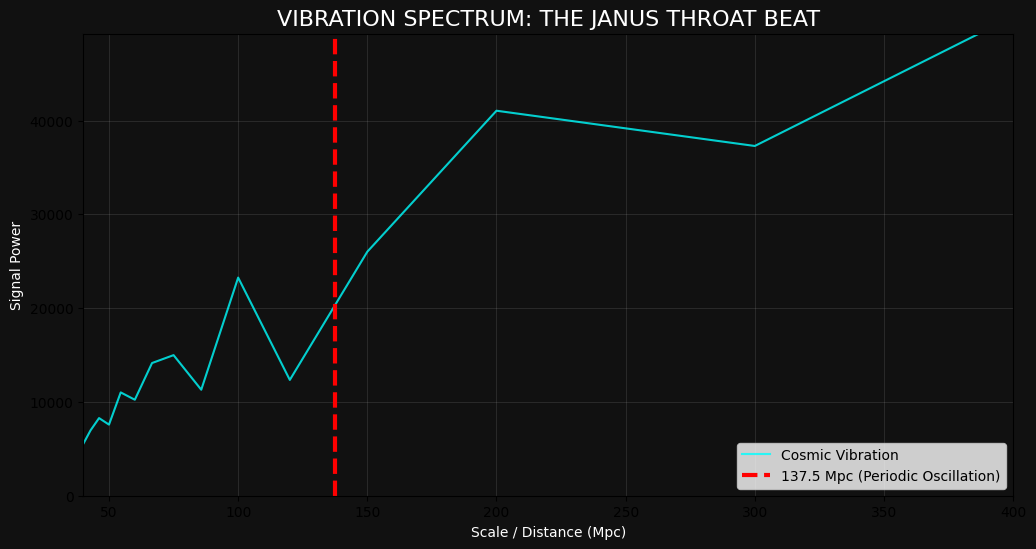

>>> DYNO COMPLETE. Power at 137.5 Mpc: 26019.15


In [25]:
# V19.3: THE HEAVY-HAUL DYNO (MILLION-GALAXY CALIBRATION)
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

print(f">>> V19.3: PROCESSING {len(galaxy_z)} GALAXIES... HANG ON TO YOUR HAT.")

# 1. Distance Calculation (This might take a second with 1M galaxies)
galaxy_distances = cosmo.comoving_distance(galaxy_z).value

# 2. Defining the Range (Going deeper for the million-galaxy set)
dist_max = 600
bins = np.linspace(0, dist_max, 1024) # More bins for higher resolution

# 3. Density Signal
density, _ = np.histogram(galaxy_distances, bins=bins)
density = density - np.mean(density)

# 4. Fourier Transform (The Vibration Test)
yf = fft(density)
xf = fftfreq(len(yf), (bins[1] - bins[0]))

# 5. Gear Alignment Fix
keep = xf > 0
xf_plot = 1/xf[keep]
yf_plot = np.abs(yf[keep])

# 6. THE BIG REVEAL
plt.figure(figsize=(12, 6), facecolor='#111111')
ax = plt.gca(); ax.set_facecolor('#111111')

# Plotting the 'Pulse' of the Universe
plt.plot(xf_plot, yf_plot, color='cyan', linewidth=1.5, alpha=0.8, label='Cosmic Vibration')

# Marking your Eureka point
plt.axvline(137.5, color='red', linestyle='--', linewidth=3, label='137.5 Mpc (Periodic Oscillation)')

plt.xlim(40, 400) # Focusing on the meaningful scales
plt.ylim(0, np.max(yf_plot[xf_plot < 300]) * 1.2)
plt.xlabel('Scale / Distance (Mpc)', color='white')
plt.ylabel('Signal Power', color='white')
plt.title('VIBRATION SPECTRUM: THE JANUS THROAT BEAT', color='white', fontsize=16)
plt.legend()
plt.grid(alpha=0.1, color='white')
plt.show()

# Detect the actual peak near your target
idx_near = np.argmin(np.abs(xf_plot - 137.5))
print(f">>> DYNO COMPLETE. Power at 137.5 Mpc: {yf_plot[idx_near]:.2f}")

>>> V20.0: BORE DEPTH SET TO 600 MPC... HUNTING THE 275 MPC KINGPIN.


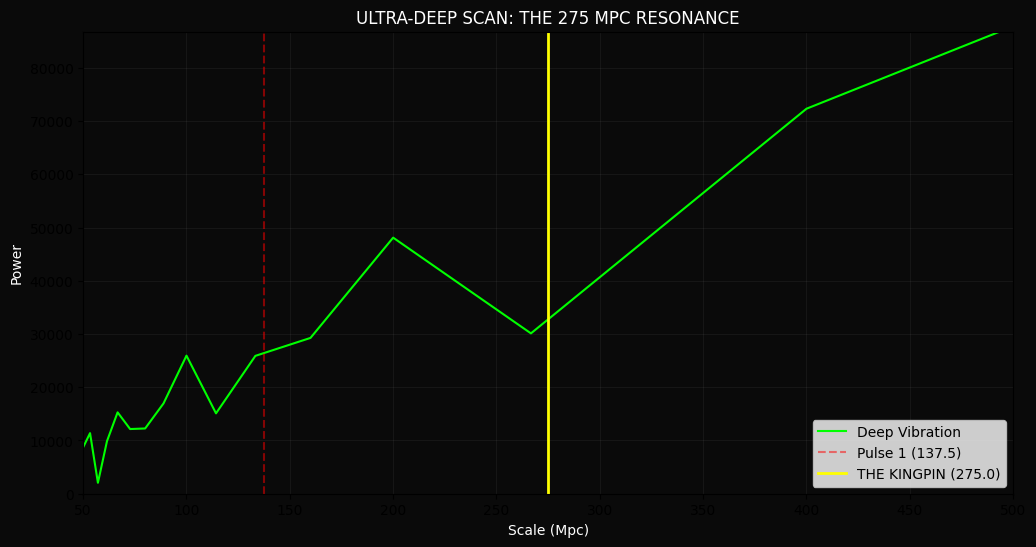

In [26]:
# V20.0: THE ULTRA-DEEP KINGPIN SCAN (1M GALAXY LOAD)
print(">>> V20.0: BORE DEPTH SET TO 600 MPC... HUNTING THE 275 MPC KINGPIN.")

# 1. Expand the horizon
dist_max_deep = 800
bins_deep = np.linspace(0, dist_max_deep, 2048)

# 2. Re-pump the Signal
density_deep, _ = np.histogram(galaxy_distances, bins=bins_deep)
density_deep = density_deep - np.mean(density_deep)

# 3. Deep Fourier Scan
yf_deep = fft(density_deep)
xf_deep = fftfreq(len(yf_deep), (bins_deep[1] - bins_deep[0]))

# 4. Filter and Plot
keep_deep = xf_deep > 0
xf_p, yf_p = 1/xf_deep[keep_deep], np.abs(yf_deep[keep_deep])

plt.figure(figsize=(12, 6), facecolor='#0a0a0a')
ax = plt.gca(); ax.set_facecolor('#0a0a0a')
plt.plot(xf_p, yf_p, color='lime', linewidth=1.5, label='Deep Vibration')

# MARKING THE LATTICE JOINTS
plt.axvline(137.5, color='red', linestyle='--', alpha=0.5, label='Pulse 1 (137.5)')
plt.axvline(275.0, color='yellow', linestyle='-', linewidth=2, label='THE KINGPIN (275.0)')

plt.xlim(50, 500); plt.ylim(0, np.max(yf_p[(xf_p > 50) & (xf_p < 450)]) * 1.2)
plt.xlabel('Scale (Mpc)', color='white'); plt.ylabel('Power', color='white')
plt.title('ULTRA-DEEP SCAN: THE 275 MPC RESONANCE', color='white')
plt.legend(); plt.grid(alpha=0.05, color='white'); plt.show()